# PyTorch Basics: Tensors & Gradients

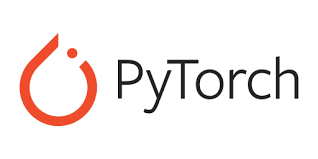



  PyTorch is an open-source machine learning framework that is primarily used for developing and training deep learning models. It was developed by Facebook's AI Research Lab and released in 2016. PyTorch provides a flexible and dynamic approach to building neural networks, making it a popular choice among researchers and developers.

The framework is built on a dynamic computational graph concept, which means that the graph is built and modified on-the-fly as the program runs. This allows for more intuitive and flexible model development, as you can use standard Python control flow statements and debug the model easily.

PyTorch supports automatic differentiation, which enables efficient computation of gradients for training neural networks using backpropagation. It provides a rich set of tools and libraries for tasks such as data loading, model building, optimization, and evaluation.

One of the key advantages of PyTorch is its support for GPU acceleration, allowing you to train models on GPUs to significantly speed up computations. It also has a large and active community, which means there are plenty of resources, tutorials, and pre-trained models available.

PyTorch is often compared to TensorFlow, another popular deep learning framework. While TensorFlow focuses more on static computation graphs, PyTorch emphasizes dynamic computation graphs. This fundamental difference in design philosophy gives PyTorch an edge when it comes to flexibility and ease of use.

Overall, PyTorch is widely used in the research community and is gaining popularity in industry applications as well. It provides a powerful and user-friendly platform for building and training deep learning models.



In [1]:
import torch

# Tensors

In [2]:
# Number/Scalar

t1 = torch.tensor(4.)
t1

# 4. is a shorthand notation for 4.0

tensor(4.)

In [3]:
t1.dtype

torch.float32

In [4]:
#Vector
t2 = torch.tensor([1., 2, 3, 4])
t2

tensor([1., 2., 3., 4.])

In [5]:
# Matrix
t3 = torch.tensor([
    [5., 6],
    [7,8],
    [9,10]
])
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [6]:
# 3 dimensional array
t4 = torch.tensor([
    [
        [11, 12, 13],
        [14, 15, 16]
    ],
    [
        [17,18,19],
        [20,21,22]
    ]
])

t4

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])

In [8]:
print(t1)
t1.shape

tensor(4.)


torch.Size([])

In [9]:
print(t2)
t2.shape

tensor([1., 2., 3., 4.])


torch.Size([4])

In [10]:
print(t3)
t3.shape

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])


torch.Size([3, 2])

In [11]:
print(t4)
t4.shape

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])


torch.Size([2, 2, 3])

# Tensor operation and gradients

In [13]:
# Create tensors

x = torch.tensor(3.)
w = torch.tensor(4. , requires_grad = True)
b = torch.tensor(5., requires_grad = True)

x, w, b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

In [14]:
# Arithemitc operations

y = w*x + b
y

tensor(17., grad_fn=<AddBackward0>)

In [15]:
# Compute derivates
y.backward()

In [16]:
# Display gradients
print("dy/dx: " ,x.grad)
print("dy/dw: ", w.grad)
print("dy/db: ", b.grad)


dy/dx:  None
dy/dw:  tensor(3.)
dy/db:  tensor(1.)


# Tensor functions

In [22]:
# Create a tensor with a fixed value for every elemnt

t6 = torch.full((3,2), 42)
t6

tensor([[42, 42],
        [42, 42],
        [42, 42]])

In [23]:
# Concatinate two tensors with compatible shapes
t7 = torch.cat((t3, t6))
t7

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.],
        [42., 42.],
        [42., 42.],
        [42., 42.]])

In [24]:
# change the sin of each element
t8 = torch.sin(t7)
t8

tensor([[-0.9589, -0.2794],
        [ 0.6570,  0.9894],
        [ 0.4121, -0.5440],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165]])

In [25]:
# change the shape of a tensor

t9 = t8.reshape(3,2,2)
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

# Interoperability with Numpy

In [26]:
import numpy as np

x = np.array([[1,2], [3, 4.]])
x

array([[1., 2.],
       [3., 4.]])

In [27]:
y = torch.from_numpy(x)
y

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

In [28]:
x.dtype, y.dtype

(dtype('float64'), torch.float64)

In [30]:
z = y.numpy()
z

array([[1., 2.],
       [3., 4.]])

# Linear Regression from Scratch using pytorch

In [31]:
import numpy as np
import torch

In [32]:
# Making training data
# Input ---> (temp, rainfall, humidity) ---> yield of apple and oranges crops

inputs = np.array([
    [73, 67,43],
    [91, 88, 64],
    [87, 134, 58],
    [102, 43, 37],
    [69, 96, 70],
], dtype = 'float32')

In [33]:
# Target (apples, oranges)

target = np.array([
    [56, 70],
    [81, 101],
    [119, 113],
    [22, 37],
    [103, 119]
], dtype = 'float32')

In [34]:
# Convert inputs and target to tensors

inputs = torch.from_numpy(inputs)
target = torch.from_numpy(target)

print(inputs)
print(target)



tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


In [64]:
# Weights and biases
w = torch.randn(2, 3, requires_grad = True)
b = torch.randn(2, requires_grad = True)

print(w)
print(b)


tensor([[-0.4381, -0.3557, -2.1575],
        [ 0.3437,  0.7292,  0.9521]], requires_grad=True)
tensor([-1.3664, -0.4123], requires_grad=True)


In [65]:
# define the model

# Z = X * W + B
def model(x):
  return x @ w.t() + b



In [66]:
# prediction
preds = model(inputs)
print(preds)

tensor([[-149.9502,  114.4780],
        [-210.6126,  155.9727],
        [-212.2760,  182.4292],
        [-141.1742,  101.2327],
        [-216.7646,  159.9566]], grad_fn=<AddBackward0>)


In [67]:
# loss funtion we will use is MSE -> Mean squared error
def MSE(y, y_hat):
  diff = y - y_hat

  return torch.sum(diff*diff)/diff.numel()

In [68]:
# error
loss = MSE(target, preds)
print(loss)

tensor(38169.6367, grad_fn=<DivBackward0>)


In [69]:
#Compute gradients
loss.backward()

In [70]:
print(w)
print(w.grad)

tensor([[-0.4381, -0.3557, -2.1575],
        [ 0.3437,  0.7292,  0.9521]], requires_grad=True)
tensor([[-21819.9277, -24313.0898, -15030.8076],
        [  4733.4976,   4762.9946,   2940.2544]])


In [71]:
print(b)
print(b.grad)

tensor([-1.3664, -0.4123], requires_grad=True)
tensor([-262.3555,   54.8138])


In [72]:
#reset grad
w.grad.zero_()
b.grad.zero_()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [73]:
# Adjust params

preds = model(inputs)

print(preds)


loss = MSE(target, preds)
print(loss)

tensor([[-149.9502,  114.4780],
        [-210.6126,  155.9727],
        [-212.2760,  182.4292],
        [-141.1742,  101.2327],
        [-216.7646,  159.9566]], grad_fn=<AddBackward0>)
tensor(38169.6367, grad_fn=<DivBackward0>)


In [74]:
loss.backward()

print(w.grad)
print(b.grad)

tensor([[-21819.9277, -24313.0898, -15030.8076],
        [  4733.4976,   4762.9946,   2940.2544]])
tensor([-262.3555,   54.8138])


In [75]:
# adjust weight & reset grad

learning_rate = 1e-5

with torch.no_grad():
  w -= w.grad * 1e-5
  b -= b.grad * 1e-5

  w.grad.zero_()
  b.grad.zero_()

In [76]:
print(w)
print(b)

tensor([[-0.2199, -0.1125, -2.0072],
        [ 0.2964,  0.6816,  0.9227]], requires_grad=True)
tensor([-1.3637, -0.4128], requires_grad=True)


In [77]:
# Calculate again

preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(25905.7031, grad_fn=<DivBackward0>)


In [78]:
# Training for muliple epochs
for i in range(400):
  preds = model(inputs)
  loss = MSE(target, preds)
  loss.backward()
  with torch.no_grad():
    w -= w.grad * 1e-5
    b -= b.grad * 1e-5

    w.grad.zero_()
    b.grad.zero_()
  print(f"Epochs({i}/{100}) & Loss {loss}")

Epochs(0/100) & Loss 25905.703125
Epochs(1/100) & Loss 17639.734375
Epochs(2/100) & Loss 12067.9482421875
Epochs(3/100) & Loss 8311.7548828125
Epochs(4/100) & Loss 5779.07763671875
Epochs(5/100) & Loss 4070.928466796875
Epochs(6/100) & Loss 2918.4326171875
Epochs(7/100) & Loss 2140.399169921875
Epochs(8/100) & Loss 1614.726806640625
Epochs(9/100) & Loss 1259.1329345703125
Epochs(10/100) & Loss 1018.1676025390625
Epochs(11/100) & Loss 854.46435546875
Epochs(12/100) & Loss 742.8419799804688
Epochs(13/100) & Loss 666.3314208984375
Epochs(14/100) & Loss 613.4966430664062
Epochs(15/100) & Loss 576.6312866210938
Epochs(16/100) & Loss 550.5420532226562
Epochs(17/100) & Loss 531.7286376953125
Epochs(18/100) & Loss 517.8328857421875
Epochs(19/100) & Loss 507.26416015625
Epochs(20/100) & Loss 498.95196533203125
Epochs(21/100) & Loss 492.17352294921875
Epochs(22/100) & Loss 486.4419860839844
Epochs(23/100) & Loss 481.42938232421875
Epochs(24/100) & Loss 476.91400146484375
Epochs(25/100) & Loss 47

In [79]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(116.3022, grad_fn=<DivBackward0>)


In [80]:
from math import sqrt
sqrt(loss)

10.784350140216022

In [81]:
preds

tensor([[ 58.7382,  67.6438],
        [ 72.7201,  97.5322],
        [137.7358, 119.6289],
        [ 30.4782,  41.4395],
        [ 79.6659, 112.8073]], grad_fn=<AddBackward0>)

In [82]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])

# Fashion MNIST Neural Net example using Pytorch

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt


In [2]:
# Download training data from open datasets

training_data = datasets.FashionMNIST(
    root = 'data',
    train= True,
    download = True,
    transform = ToTensor(),
)

# Download test data from open datasets

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download = True,
    transform = ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 5.05MB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 55.9MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.31MB/s]


Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [3]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [4]:
batch_size = 64

# Create data loaders

train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
  print("Shape of X [N, C, H, W] ", X.shape)
  print("Shape of y: ", y.shape, y.dtype)
  break

Shape of X [N, C, H, W]  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [5]:
# Get cpu or gpu device for training

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [6]:
# Define the NN Model
class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten = nn.Flatten()

    # Hidden Layers with ReLU activation function
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10) # Output layer
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model= NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [8]:
# Cross Entropy Loss ----> Because it is a multiclass classification problem

loss_fn = nn.CrossEntropyLoss()

# Optimizer ---> SGD ---> Stochastic Gradient Descent
# lr = Learning Rate
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [9]:
# Model Training

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device) # related to gpu computation

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # BackPropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch %100 ==0 :
      loss, current = loss.item(), batch * len(X)
      print(f"Loss: {loss} [{current}/{size}]")

In [13]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)

  num_batches = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)

      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches # average loss per batch
  correct /= size # %age of correct predictions or accuracy

  print(f"Test Error: \n Accuracy: {100*correct} %, Avg loss {test_loss}\n")




In [16]:
epochs = 1
for t in range(epochs):
  print(f"Epoch {t+1} \n --------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)

print("Done\n")

Epoch 1 
 --------------------------
Loss: 0.7453593611717224 [0/60000]
Loss: 0.8441538214683533 [6400/60000]
Loss: 0.6057318449020386 [12800/60000]
Loss: 0.8170516490936279 [19200/60000]
Loss: 0.730737030506134 [25600/60000]
Loss: 0.6974841952323914 [32000/60000]
Loss: 0.8081368207931519 [38400/60000]
Loss: 0.7774155139923096 [44800/60000]
Loss: 0.7685599327087402 [51200/60000]
Loss: 0.7447283267974854 [57600/60000]
Test Error: 
 Accuracy: 73.24000000000001 %, Avg loss 0.7387217583170362

Done



In [17]:
#save model
torch.save(model.state_dict(), "model.pth")
print("Saved model state to model.pth")

Saved model state to model.pth


In [25]:
## Prediction

classes = [
    "T-shirt/top",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Ankle boot"

]


model.eval()

x, y = test_data[10][0], test_data[10][1]
x = x.to(device)
# y = y.to(device)
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]

  print(f"Predicted: {predicted} Actual: {actual}")




Predicted: Coat Actual: Coat


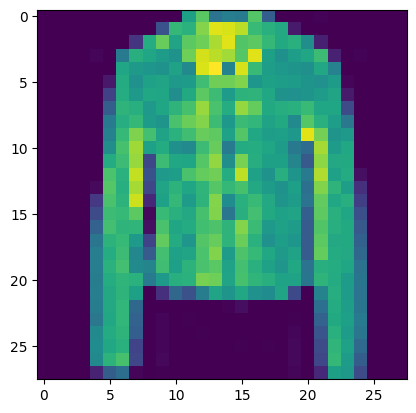

In [26]:
import matplotlib.pyplot as plt

# Assuming 'x' contains the image data
plt.imshow(x.cpu().squeeze())  # Move tensor to CPU if using GPU
plt.show()